In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 공통 색
COLOR_TARGET = '#3D5AFE' # 탐색 후 이탈
COLOR_OTHER = '#C9CDD2' # 나머지
COLOR_SUB = '#8A94A6' # 보조

# 그룹 라벨 통일 매핑
GROUP_LABEL = {'explore_fail': '탐색 후 이탈', 'pass_to_view_item': '도달'}

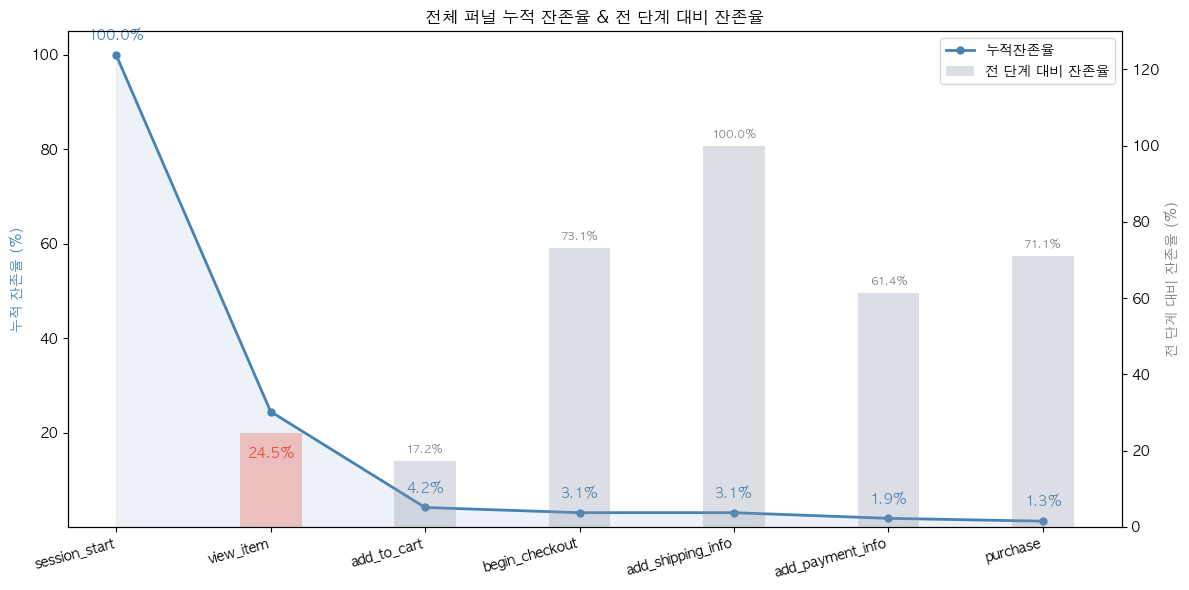

In [8]:
# 퍼널 분석
df_funnel = pd.read_csv('data/01_funnel.csv')

# 누적 잔존율 - retention, drop_off 이미 존재
base = df_funnel.loc[df_funnel['stage'] == 'session_start', 'cnt'].values[0]
df_funnel['cumulative_rate'] = (df_funnel['cnt'] / base * 100).round(1)

x = list(range(len(df_funnel)))
stages = df_funnel['stage'].tolist()

fig, ax1 = plt.subplots(figsize=(12, 6))

# 1) 누적 잔존율
ax1.plot(x, df_funnel['cumulative_rate'], 
         marker='o', linewidth=2, markersize=5, 
         color='steelblue', label='누적잔존율', zorder=5)
ax1.fill_between(x, df_funnel['cumulative_rate'], alpha=0.1, color='steelblue')
ax1.set_ylabel('누적 잔존율 (%)', color='steelblue')
ax1.set_ylim(0.115)

# 2) 전 단계 대비 잔존율
ax2 = ax1.twinx()
ax1.grid(False)
ax2.grid(False)
colors = ['#e74c3c' if i == 1 else COLOR_SUB for i in range(len(df_funnel))]
ax2.bar(x, df_funnel['retention_rate'],
        color=colors, alpha=0.3, width=0.4, label='전 단계 대비 잔존율')
ax2.set_ylabel('전 단계 대비 잔존율 (%)', color='gray')
ax2.set_ylim(0, 130)

# 3) 누적 잔존율 값 라벨 (view_item만 강조)
for i, val in enumerate(df_funnel['cumulative_rate']):
    is_viewitem = df_funnel['stage'].iloc[i] == 'view_item'
    y_offset = -10 if is_viewitem else 3
    ax1.text(i, val + y_offset, f'{val:.1f}%', ha='center',
             fontsize=10, fontweight='bold',
             color='#e74c3c' if is_viewitem else 'steelblue')

# 4) 전 단계 대비 잔존율 값 라벨 (view_item 제외, NaN 제외)
for i, val in enumerate(df_funnel['retention_rate']):
    is_viewitem = df_funnel['stage'].iloc[i] == 'view_item'
    if pd.notna(val) and not is_viewitem:
        ax2.text(i, val + 2, f'{val:.1f}%', ha='center', fontsize=8, color='gray')

ax1.set_xticks(x)
ax1.set_xticklabels(stages, rotation=15, ha='right')
ax1.set_title('전체 퍼널 누적 잔존율 & 전 단계 대비 잔존율',
              fontsize=12, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('images/01_funnel.png', dpi=200, bbox_inches='tight')
plt.show()

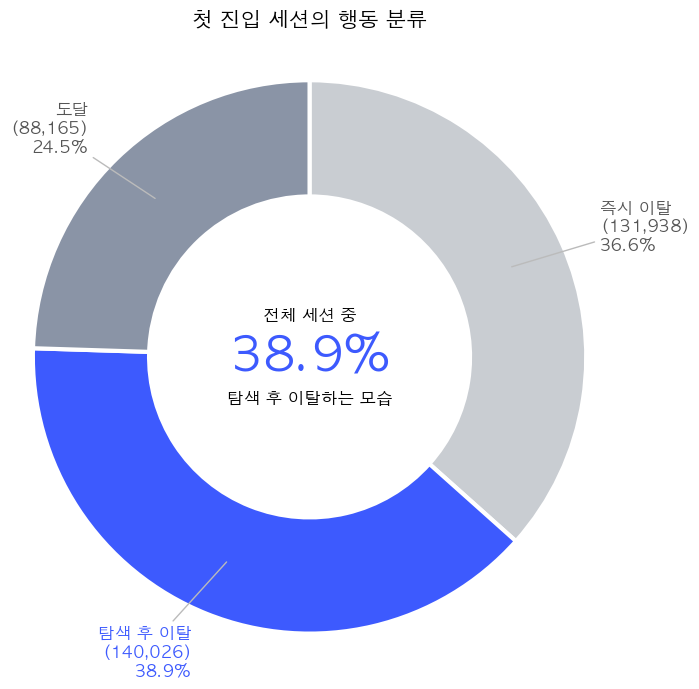

In [9]:
# 첫 진입 세션 행동 분류
df_segment = pd.read_csv('data/02_segment_classfication.csv')

# 도넛 순서: 즉시이탈 -> 탐색후이탈(타겟) -> 도달
order = ['즉시 이탈', '탐색 후 이탈', '도달']
df_segment = df_segment.set_index('session_type').loc[order].reset_index()

color_map = {
    '즉시 이탈': COLOR_OTHER,
    '탐색 후 이탈': COLOR_TARGET,
    '도달': COLOR_SUB,
}
color_list = [color_map[t] for t in df_segment['session_type']]

fig, ax = plt.subplots(figsize=(7, 7))

wedges, _ = ax.pie(
    df_segment['percentage'],
    colors=color_list,
    startangle=90,
    counterclock=False,
    wedgeprops=dict(width=0.42, edgecolor='white', linewidth=3),  # width<1 = 도넛
)

# 조각 바깥 라벨 (선 연결)
for w, (_, row) in zip(wedges, df_segment.iterrows()):
    ang = (w.theta2 + w.theta1) / 2
    xc, yc = np.cos(np.radians(ang)), np.sin(np.radians(ang))
    ha = 'left' if xc > 0 else 'right'
    is_target = row['session_type'] == '탐색 후 이탈'
    ax.annotate(
        f"{row['session_type']}\n({row['total_sessions']:,})\n{row['percentage']}%",
        xy=(xc*0.79, yc*0.79),
        xytext=(xc*1.15, yc*1.15),
        ha=ha, va='center',
        fontsize=12,
        fontweight='bold' if is_target else 'normal',
        color=COLOR_TARGET if is_target else '#555555',
        arrowprops=dict(arrowstyle='-', color='#BBBBBB', lw=1),
    )

# 도넛 가운데 메시지
target = df_segment[df_segment['session_type'] == '탐색 후 이탈'].iloc[0]
ax.text(0, 0.15, "전체 세션 중", ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(0, 0, f"{target['percentage']}%", ha='center', va='center',
        fontsize=34, fontweight='bold', color=COLOR_TARGET)
ax.text(0, -0.15, "탐색 후 이탈하는 모습", ha='center', va='center', fontsize=12, fontweight='bold')

ax.set_title('첫 진입 세션의 행동 분류', fontsize=15, fontweight='bold', pad=20)
ax.axis('equal')

plt.tight_layout()
plt.savefig('images/02_segment.png', dpi=200, bbox_inches='tight')
plt.show()

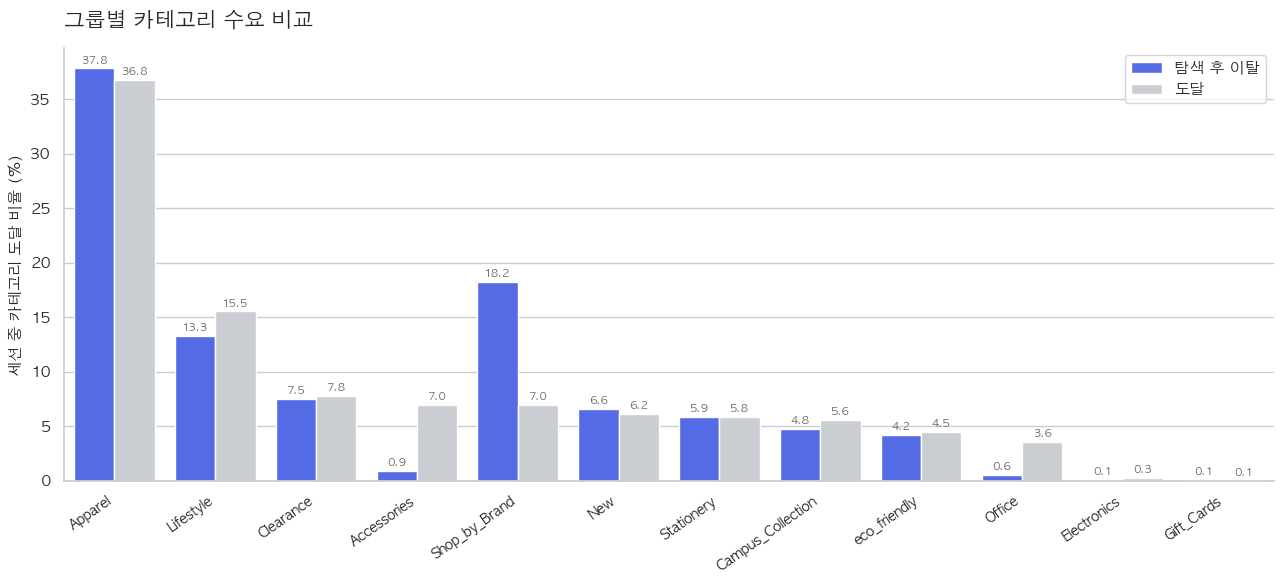

In [ ]:
# 그룹별 카테고리 수요 비교
df_cat = pd.read_csv('../data/03_category_demand.csv')

# 비교 대상 두 그룹만 (즉시이탈 제외)
df_cat = df_cat[df_cat['fail_type'].isin(GROUP_LABEL)].copy()
df_cat['그룹'] = df_cat['fail_type'].map(GROUP_LABEL)
df_cat['pct'] = df_cat['ratio'] * 100

# 카테고리 정렬: 도달 그룹 비율 높은 순
cat_order = (df_cat[df_cat['fail_type'] == 'pass_to_view_item']
             .sort_values('pct', ascending=False)['category'].tolist())

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(
    data=df_cat, x='category', y='pct', hue='그룹',
    order=cat_order,
    hue_order=['탐색 후 이탈', '도달'],
    palette={'탐색 후 이탈': COLOR_TARGET, '도달': COLOR_OTHER},
    ax=ax,
)

ax.set_xlabel('')
ax.set_ylabel('세션 중 카테고리 도달 비율 (%)', fontsize=11)
ax.set_title('그룹별 카테고리 수요 비교', fontsize=15, fontweight='bold', loc='left', pad=15)
plt.xticks(rotation=35, ha='right', fontsize=10)
ax.legend(title='', fontsize=11, loc='upper right')

for c in ax.containers:
    ax.bar_label(c, fmt='%.1f', fontsize=8, padding=2, color='#666666')

sns.despine()
plt.tight_layout()
plt.savefig('../images/03_category_demand.png', dpi=200, bbox_inches='tight')
plt.show()

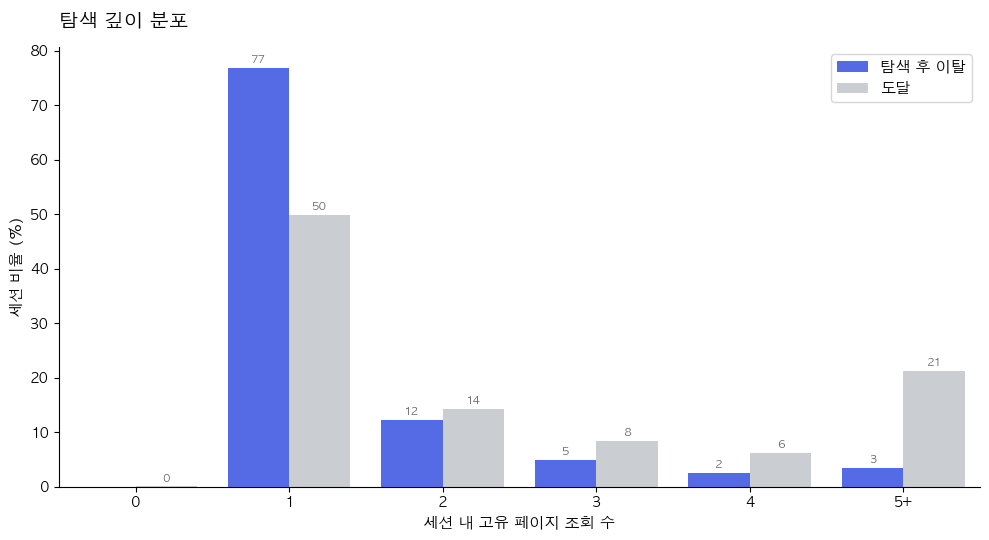

In [10]:
# 탐색 깊이 분포 (가설 검증: 탐색량 <-> 도달)
df_depth = pd.read_csv('data/04_explore_depth.csv')

# 비교 대상 두 그룹만
df_depth = df_depth[df_depth['fail_type'].isin(GROUP_LABEL)].copy()
df_depth['그룹'] = df_depth['fail_type'].map(GROUP_LABEL)

# depth_bin 정렬 (CSV에 존재하는 구간만)
bin_order = [b for b in ['0', '1', '2', '3', '4', '5+'] if b in df_depth['depth_bin'].astype(str).values]
df_depth['depth_bin'] = df_depth['depth_bin'].astype(str)

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(
    data=df_depth, x='depth_bin', y='pct', hue='그룹',
    order=bin_order,
    hue_order=['탐색 후 이탈', '도달'],
    palette={'탐색 후 이탈': COLOR_TARGET, '도달': COLOR_OTHER},
    ax=ax,
)
ax.set_xlabel('세션 내 고유 페이지 조회 수', fontsize=11)
ax.set_ylabel('세션 비율 (%)', fontsize=11)
ax.set_title('탐색 깊이 분포', fontsize=14, fontweight='bold', loc='left', pad=15)
ax.legend(title='', fontsize=11)

for c in ax.containers:
    ax.bar_label(c, fmt='%.0f', fontsize=8, padding=2, color='#666666')

sns.despine()
plt.tight_layout()
plt.savefig('images/04_explore_depth.png', dpi=200, bbox_inches='tight')
plt.show()